<a href="https://colab.research.google.com/github/vberezina/machine-learning-basics/blob/main/practices/LR6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ЛАБОРАТОРНАЯ РАБОТА №6. Линейная регрессия

## Теоретический минимум




### Линейная модель и МНК

Линейная регрессия — это метод поиска зависимости между признаками $X$ и целевой переменной $y$ в виде линейной комбинации:


$$y = w_0x_0 + w_1x_1 + \dots + w_nx_n = Xw$$

Для поиска оптимальных весов $w$ используется **метод наименьших квадратов (МНК)**. Его суть — минимизировать сумму квадратов остатков (ошибок) между реальным значением и предсказанием:


$$RSS(w) = \sum_{i=1}^{m} (y^{(i)} - \hat{y}^{(i)})^2 \to \min$$

### Нормальное уравнение

В отличие от градиентного спуска, линейная регрессия имеет аналитическое (точное) решение. Если мы возьмем производную от функции ошибки по весам $w$ и приравняем её к нулю, мы получим **нормальное уравнение**:


$$\hat{w} = (X^T X)^{-1} X^T y$$

**Условия применимости:**

* матрица $X^T X$ должна быть невырожденной (её определитель не равен нулю).
* количество признаков не должно быть слишком огромным (так как инверсия матрицы — ресурсоемкая операция $O(n^3)$).

### Проблема недообучения (Underfitting)

Классическая линейная регрессия строит «глобальную» модель — одну прямую линию для всех данных. Если реальная зависимость нелинейна (например, имеет форму синусоиды или параболы), прямая линия будет давать большую ошибку, так как она слишком проста для этих данных.

### Локально взвешенная линейная регрессия (LWLR)

Чтобы решить проблему недообучения без усложнения модели до полиномов, используют **LWLR**. Идея в том, что для предсказания значения в конкретной точке мы придаем больше веса «соседям» и почти игнорируем далекие точки.

В LWLR веса $w$ вычисляются для каждого запроса заново путем минимизации взвешенной ошибки:


$$\sum_{i} w^{(i)} (y^{(i)} - \hat{y}^{(i)})^2$$

#### Ядро взвешивания

Чаще всего используется Гауссово ядро. Вес $i$-й точки относительно точки прогноза $x$ равен:


$$w(i,i) = \exp \left( \frac{(x^{(i)} - x)^2}{-2k^2} \right)$$

* **Параметр $k$** (параметр сглаживания) определяет «ширину» окна. Чем он меньше, тем только более близкие соседи влияют на результат.

### Компромисс смещения и дисперсии

Параметр $k$ в LWLR напрямую управляет сложностью модели:

1. **Высокое смещение (Bias):** При большом $k$ модель слишком гладкая (как обычный МНК).
2. **Высокая дисперсия (Variance):** При очень маленьком $k$ модель начинает учитывать шум в данных, «дергаясь» за каждой случайной точкой. Это ведет к **переобучению**.



## Учебная задача


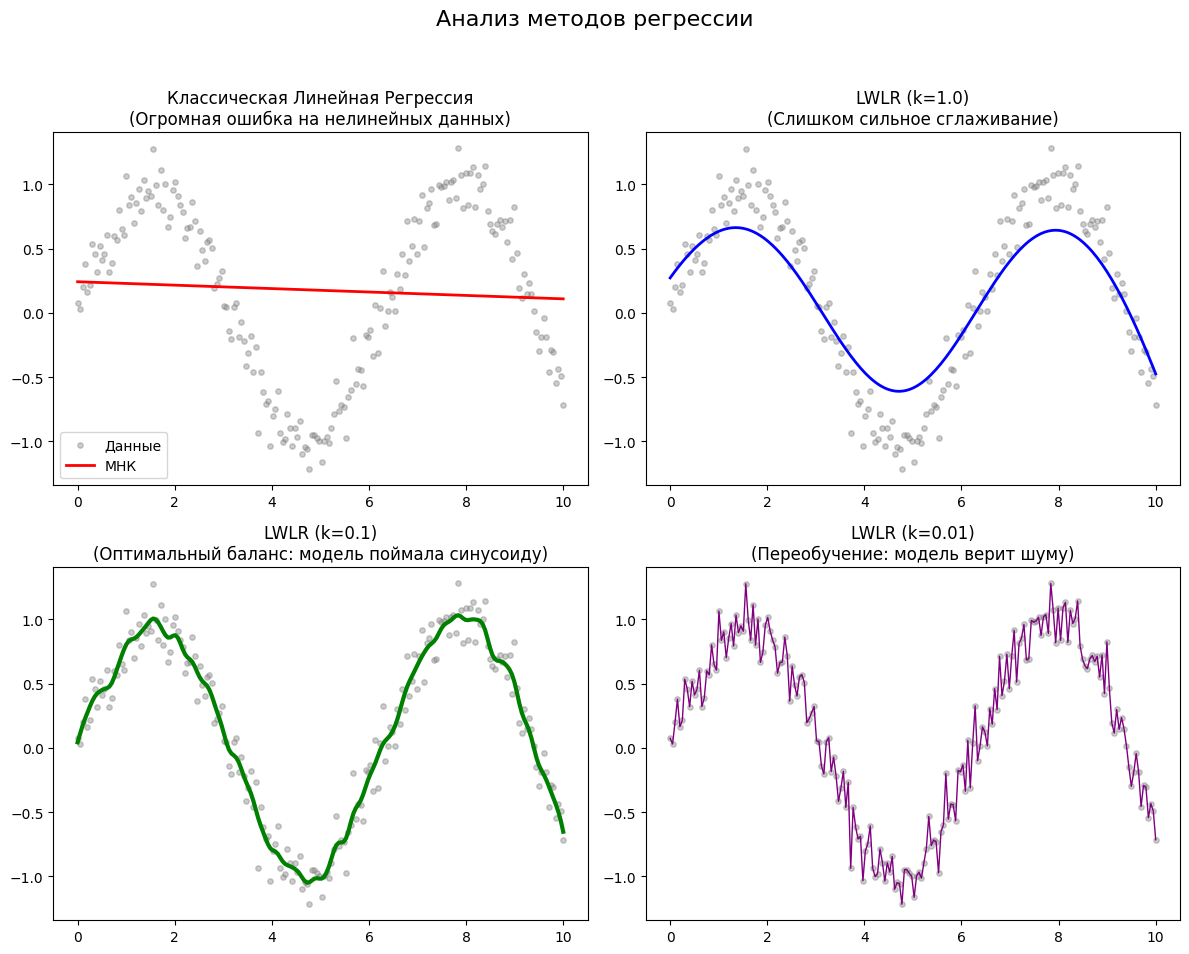

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Генерация данных ---

def generate_synthetic_data(n_samples=200):
    """
    Создает набор данных с нелинейной зависимостью.
    Это позволяет увидеть разницу между простой прямой и гибкой кривой LWLR.
    """
    np.random.seed(42)
    # Генерируем значения x от 0 до 10
    x = np.linspace(0, 10, n_samples)

    # Целевая переменная y = sin(x) + случайный шум
    y = np.sin(x) + np.random.normal(0, 0.15, n_samples)

    # В регрессии нам нужно добавить "фиктивный" признак x0 = 1 для каждой точки.
    # Это позволяет алгоритму найти свободный член (пересечение с осью Y).
    # Превращаем одномерный массив в матрицу n_samples x 2
    x_with_bias = np.vstack([np.ones(n_samples), x]).T
    return x_with_bias, y

# --- 2. Классическая линейная регрессия (МНК) ---

def standRegres(xArr, yArr):
    """
    Реализация Метода Наименьших Квадратов (МНК) через нормальное уравнение.
    Находит единый вектор весов 'w', который минимизирует общую ошибку по всей выборке.
    """
    # Преобразуем входные списки в матрицы для удобства линейной алгебры
    xMat = np.asmatrix(xArr)
    yMat = np.asmatrix(yArr).T

    # Вычисляем произведение X^T * X
    xTx = xMat.T * xMat

    # Если определитель матрицы xTx равен 0, значит признаки зависимы (мультиколлинеарность).
    # В таком случае обратную матрицу найти нельзя.
    if np.linalg.det(xTx) == 0.0:
        print("Ошибка: Матрица вырожденная (сингулярная).")
        return None

    # Формула МНК: w = (X^T * X)^-1 * X^T * y
    # .I — вычисляет обратную матрицу
    ws = xTx.I * (xMat.T * yMat)
    return ws

# --- 3. Локально взвешенная линейная регрессия (LWLR) ---

def lwlr(testPoint, xArr, yArr, k=1.0):
    """
    LWLR делает предсказание для КОНКРЕТНОЙ точки (testPoint).
    Для этого она придает разный "вес" точкам обучающей выборки:
    чем ближе точка к testPoint, тем больше её влияние на результат.
    """
    xMat = np.asmatrix(xArr)
    yMat = np.asmatrix(yArr).T

    m = np.shape(xMat)[0]

    # Инициализируем веса как диагональную матрицу (m x m) из единиц.
    # weights[j,j] будет хранить вес j-й точки обучающей выборки.
    weights = np.asmatrix(np.eye(m))

    for j in range(m):
        # Вычисляем разность (расстояние) между тестовой точкой и j-й точкой выборки
        diffMat = testPoint - xMat[j, :]

        # Гауссово ядро (Экспоненциальное затухание):
        # Вес = exp( - (расстояние)^2 / (2 * k^2) )
        # Если k маленькое — учитываются только самые близкие соседи.
        # Если k большое — влияние распределяется почти равномерно.
        weights[j, j] = np.exp(diffMat * diffMat.T / (-2.0 * k**2)).item()

    # Решаем модифицированное нормальное уравнение: w = (X^T * W * X)^-1 * X^T * W * y
    xTx = xMat.T * (weights * xMat)

    if np.linalg.det(xTx) == 0.0:
        return None

    ws = xTx.I * (xMat.T * (weights * yMat))

    # Возвращаем предсказанное значение: y_hat = x * w
    return (testPoint * ws).item()

def lwlrTest(testArr, xArr, yArr, k=1.0):
    """
    В отличие от обычной регрессии, где мы считаем веса один раз,
    в LWLR мы должны заново обучать модель для КАЖДОЙ точки теста.
    """
    m = np.shape(testArr)[0]
    yHat = np.zeros(m)
    for i in range(m):
        res = lwlr(testArr[i], xArr, yArr, k)
        yHat[i] = res if res is not None else 0.0
    return yHat

# --- 4. Визуализация результатов ---

def run_comparison():
    # 1. Получаем данные
    xArr, yArr = generate_synthetic_data()

    # 2. Обучаем стандартную регрессию (всегда дает прямую линию)
    ws = standRegres(xArr, yArr)
    yHat_std = np.array(np.asmatrix(xArr) * ws).flatten()

    # 3. Вычисляем предсказания LWLR для разных k
    # k = 1.0 : Почти прямая (модель слишком простая)
    yHat_k1 = lwlrTest(xArr, xArr, yArr, k=1.0)
    # k = 0.1 : Оптимальная кривая, повторяющая синусоиду
    yHat_k01 = lwlrTest(xArr, xArr, yArr, k=0.1)
    # k = 0.01 : Модель начинает "дергаться", пытаясь попасть в каждую точку шума
    yHat_k001 = lwlrTest(xArr, xArr, yArr, k=0.01)

    # Настройка графиков
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Анализ методов регрессии', fontsize=16)

    # Индексы для сортировки (чтобы линия на графике была плавной, а не зигзагом)
    srtInd = xArr[:, 1].argsort()

    # Отрисовка МНК
    axs[0, 0].scatter(xArr[:, 1], yArr, s=15, color='gray', alpha=0.4, label='Данные')
    axs[0, 0].plot(xArr[:, 1], yHat_std, color='red', lw=2, label='МНК')
    axs[0, 0].set_title('Классическая Линейная Регрессия\n(Огромная ошибка на нелинейных данных)')
    axs[0, 0].legend()

    # Отрисовка LWLR k=1.0
    axs[0, 1].scatter(xArr[:, 1], yArr, s=15, color='gray', alpha=0.4)
    axs[0, 1].plot(xArr[srtInd, 1], yHat_k1[srtInd], color='blue', lw=2)
    axs[0, 1].set_title('LWLR (k=1.0)\n(Слишком сильное сглаживание)')

    # Отрисовка LWLR k=0.1
    axs[1, 0].scatter(xArr[:, 1], yArr, s=15, color='gray', alpha=0.4)
    axs[1, 0].plot(xArr[srtInd, 1], yHat_k01[srtInd], color='green', lw=3)
    axs[1, 0].set_title('LWLR (k=0.1)\n(Оптимальный баланс: модель поймала синусоиду)')

    # Отрисовка LWLR k=0.01
    axs[1, 1].scatter(xArr[:, 1], yArr, s=15, color='gray', alpha=0.4)
    axs[1, 1].plot(xArr[srtInd, 1], yHat_k001[srtInd], color='purple', lw=1)
    axs[1, 1].set_title('LWLR (k=0.01)\n(Переобучение: модель верит шуму)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    run_comparison()

## Задания


### Задание №1. Метод наименьших квадратов


1. Напишите функцию, которая вычисляет вектор весов $w$ по формуле:

$$\hat{w} = (X^T X)^{-1} X^T y$$


2. Включите в функцию проверку матрицы $X^T X$ на вырожденность (проверка определителя), чтобы избежать ошибок при инвертировании.
3. Подготовьте данные: добавьте к вектору признаков столбец единиц ($x_0$), чтобы модель могла учитывать свободный член (смещение).
4. Визуализируйте результат, построив прямую линию поверх облака точек.






### Задание №2. Локально взвешенная регрессия (LWLR)



1. Реализуйте функцию, которая выполняет предсказание для конкретной точки, придавая веса её соседям.
2. Используйте **Гауссово ядро** для формирования диагональной матрицы весов $W$. Вес каждой точки $j$ должен вычисляться как:

$$w(j,j) = \exp\left(\frac{|x^{(j)} - testPoint|^2}{-2k^2}\right)$$


3. Реализуйте функцию, которая итеративно вызывает функцию из п.1 для каждого элемента тестовой выборки.
4. Убедитесь в корректности типов данных: используйте метод `.item()` для извлечения скалярных значений из матриц NumPy.










### Задание №3: Исследование влияния параметра сглаживания и переобучения


1. Проведите эксперимент, используя три значения параметра $k$ для LWLR:
* $k = 1.0$ (сильное сглаживание);
* $k = 0.1$ (оптимальное сглаживание);
* $k = 0.01$ (минимальное сглаживание).


2. Постройте графики для каждого случая и сравните их с результатом классического МНК из Задания №1.




## Контрольные вопросы

1. Почему метод называется методом «наименьших квадратов»? Почему мы минимизируем квадрат ошибки $(y - \hat{y})^2$, а не модуль ошибки $|y - \hat{y}|$?
2. Зачем в матрицу признаков $X$ принудительно добавляется столбец единиц? Как изменится график регрессии, если этого не сделать?

3. Почему для больших датасетов (например, 1 000 000 записей) LWLR использовать практически невозможно, в то время как обычный МНК работает быстрее?

4. Как формируется матрица весов в LWLR? Почему она диагональная и как её размер зависит от количества обучающих примеров?




